In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [12]:
df = pd.read_csv("D:/DS_Job_Acceptance_Prediction/Data/job_acceptance.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [13]:
df.shape

(19158, 14)

In [14]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [16]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [17]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [53]:
cat_cols = [
    'gender',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'company_size',
    'company_type',
    'last_new_job'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [54]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [18]:
df = df.dropna()

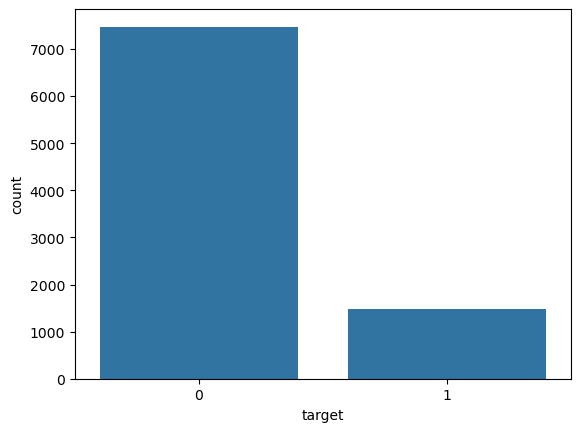

In [55]:
#Target Variable Distribution

sns.countplot(x="target", data=df)
plt.show()

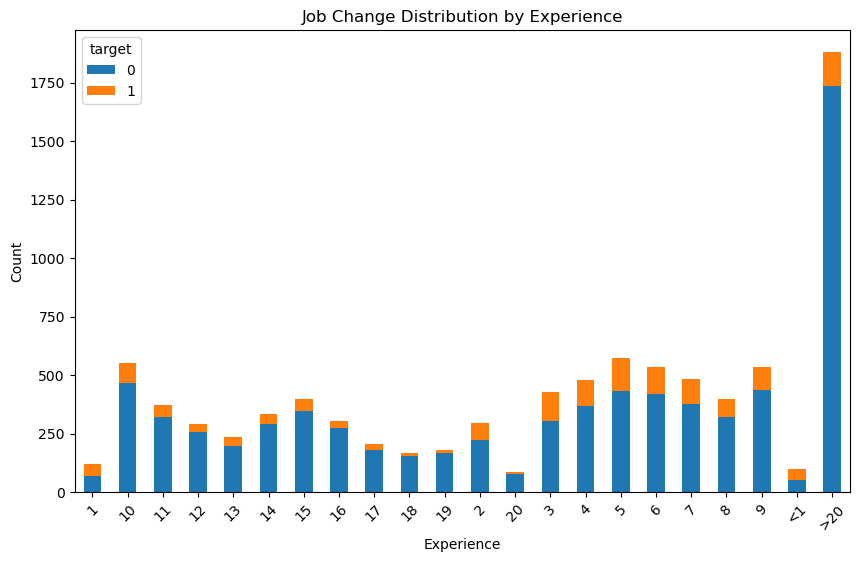

In [20]:
#Job Change Rate by Experience (Stacked Bar Chart)

exp_target = pd.crosstab(df['experience'], df['target'])

exp_target.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Job Change Distribution by Experience")
plt.xlabel("Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

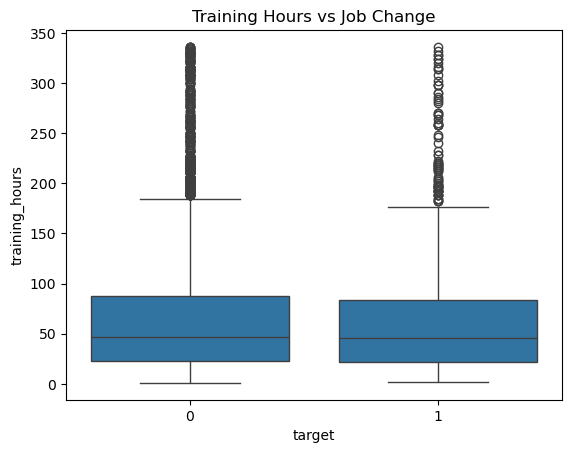

In [56]:
#Training Hours vs Job Change (Box Plot)

sns.boxplot(x='target', y='training_hours', data=df)

plt.title("Training Hours vs Job Change")
plt.show()

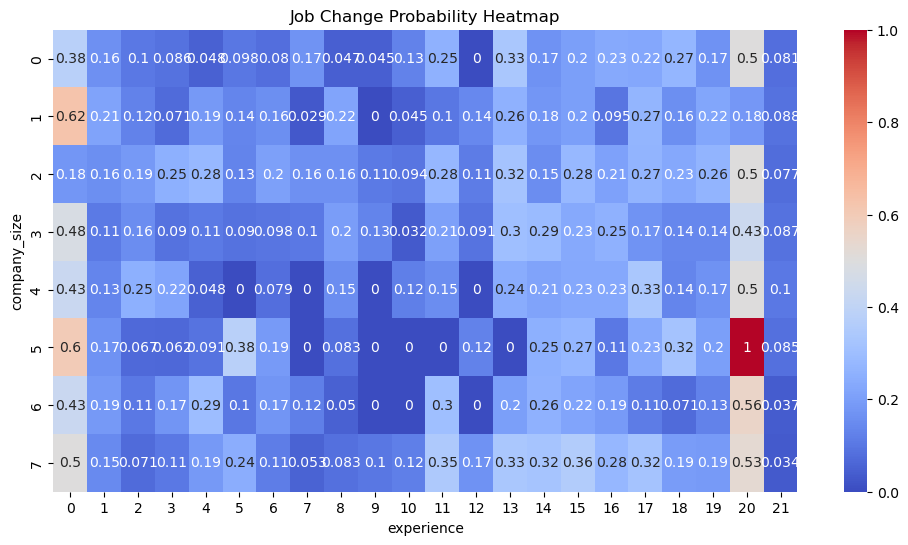

In [57]:
#Company Size vs Job Change (Heatmap)

pivot = pd.pivot_table(
    df,
    values='target',
    index='company_size',
    columns='experience',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Job Change Probability Heatmap")
plt.show()

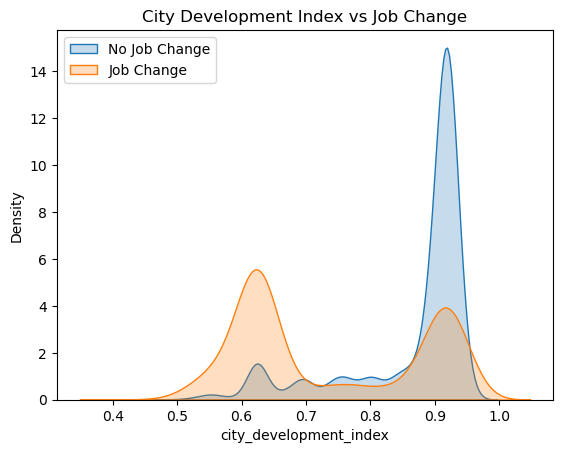

In [23]:
#City Development Index Distribution (KDE Plot)

sns.kdeplot(
    df[df['target']==0]['city_development_index'],
    label='No Job Change',
    fill=True
)

sns.kdeplot(
    df[df['target']==1]['city_development_index'],
    label='Job Change',
    fill=True
)

plt.title("City Development Index vs Job Change")
plt.legend()
plt.show()

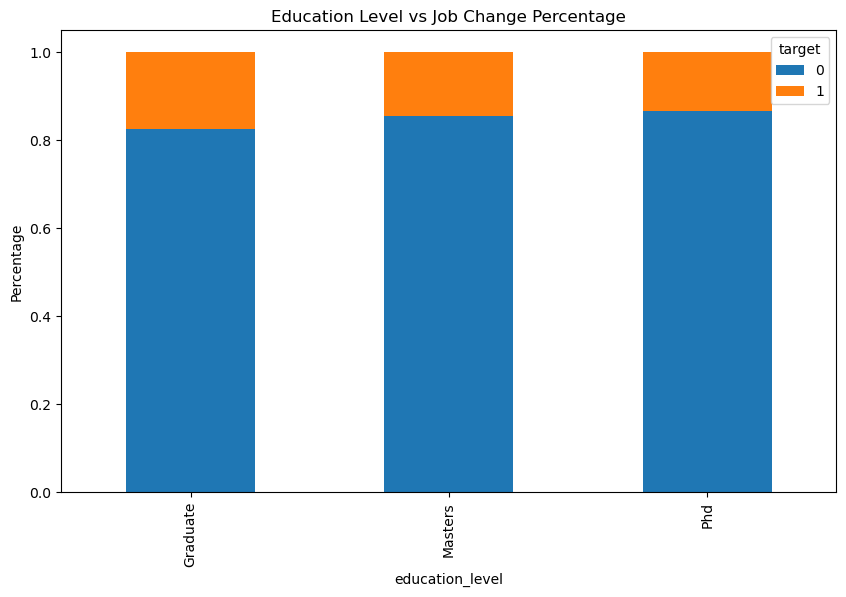

In [24]:
#Education vs Job Change (100% Stacked Chart)

edu = pd.crosstab(df['education_level'], df['target'], normalize='index')

edu.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Education Level vs Job Change Percentage")
plt.ylabel("Percentage")
plt.show()

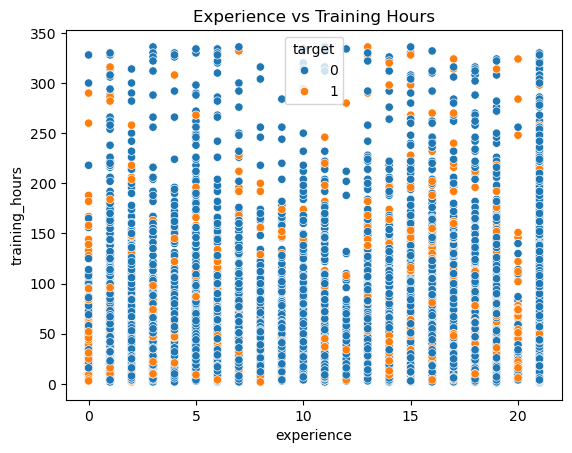

In [58]:
#Experience vs Training Hours (Scatter Plot)

sns.scatterplot(
    x='experience',
    y='training_hours',
    hue='target',
    data=df
)

plt.title("Experience vs Training Hours")
plt.show()

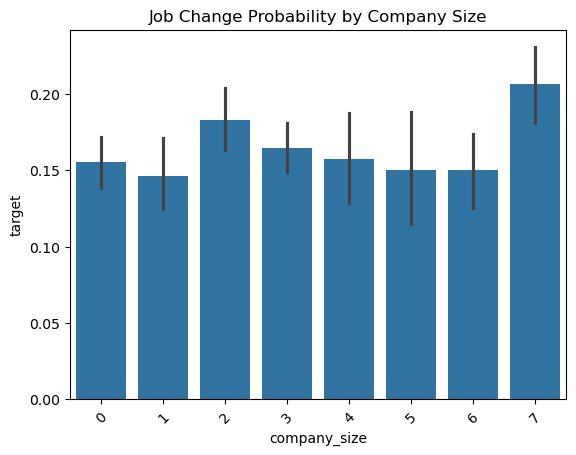

In [59]:
sns.barplot(
    x='company_size',
    y='target',
    data=df
)

plt.title("Job Change Probability by Company Size")
plt.xticks(rotation=45)
plt.show()

In [27]:
df.select_dtypes(include='object').columns

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [29]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1,29725,72,0.776,1,1,2,0,5,6,3,5,4,47,0
4,666,48,0.767,1,0,2,1,5,21,3,1,3,8,0
7,402,78,0.762,1,0,2,0,5,4,6,5,4,18,1
8,27107,5,0.920,1,0,2,0,5,17,3,5,0,46,1
11,23853,5,0.920,1,0,2,0,5,15,5,5,0,108,0


In [30]:
X = df.drop("target", axis=1)
y = df["target"]

In [31]:
X.shape
y.shape

(8955,)

In [32]:
#Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
X_train.shape
X_test.shape

(1791, 13)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
lr = LogisticRegression(max_iter=1000, solver='liblinear')

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [40]:
y_pred_lr = lr.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.8492462311557789

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1511
           1       0.54      0.23      0.32       280

    accuracy                           0.85      1791
   macro avg       0.71      0.60      0.62      1791
weighted avg       0.82      0.85      0.82      1791



In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
y_pred_rf = rf.predict(X_test)

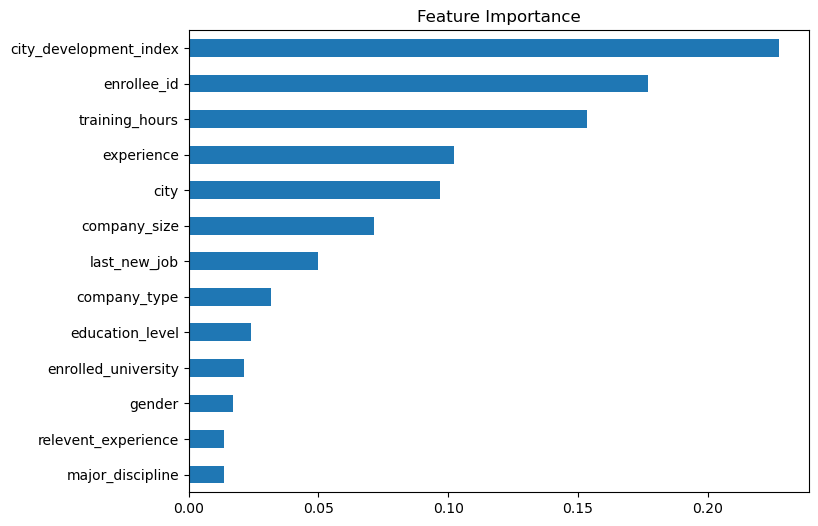

In [60]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.show()

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf = RandomForestClassifier()

In [48]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [50]:
import pickle

pickle.dump(
    rf,
    open("D:/DS_Job_Acceptance_Prediction/model/job_prediction_model.pkl", "wb")
)